In [17]:
import pandas as pd
import folium
import matplotlib.pyplot as plt
import numpy as np
import json
import geopandas as gpd
import unicodedata

In [18]:
# Mal nutricion CSV:

df_2= pd.read_csv('osb_seguridad_alimentaria-alimentacionsaludable (1).csv', encoding='cp1252', sep=';')
df_2 = df_2.rename(columns={"ï»¿AÃ±o": "Año", "Porcentaje": "Porcentaje(%)"})
df_2["Porcentaje(%)"] = df_2["Porcentaje(%)"].str.replace(',', '.', regex=False).astype(float)
df_2["Localidad"] = df_2["Localidad"].replace({"UsaquÃ©n":"Usaquén","San CristÃ³bal":"San Cristóbal"
,"FontibÃ³n":"Fontibón","EngativÃ¡":"Engativá","Los MÃ¡rtires":"Los Mártires","Antonio NariÃ±o":"Antonio Nariño", "Ciudad BolÃ­var":"Ciudad Bolívar", "BogotÃ¡ D.C.":"Bogotá D.C."})
df_2["Respuesta"] = df_2["Respuesta"].replace({"SÃ­":"Sí"})

In [24]:
#Censo DANE 2018:

censo2018 ={
    "Nombre Localidad":["Usaquén","Chapinero","Santa Fé","San Cristobal","Usme","Tunjuelito","Bosa","Kennedy","Fontibón","Engativá",
                        "Suba","Barrios Unidos","Teusaquillo","Los Mártires","Antonio Nariño","Puente Aranda","Candelaria","Rafael Uribe Uribe","Ciudad Bolívar","Sumapaz","Sin identificar","Total"],
    "Población 2018":[518863,151573,100260,371891,348223,165891,671181,987731,354322,768777,1115462,126294,139643,69966,76646,
                      231090,15959,344769,589088,1906,5,7149540]
    }
df_censo2018 = pd.DataFrame(censo2018)
Total_pob_2018 = df_censo2018.iloc[21,1]

In [25]:
#Tasa de crecimiento poblacional DANE

df_raw= pd.read_excel(r"C:\Users\USER\Desktop\Tomas JR\Alimentacion\Bogota (1).xls",)
df_tasas = df_raw.iloc[29:32]
df_tasas.columns = df_raw.iloc[25]
df_tasas = df_tasas.dropna(axis=1, how="all")
df_tasas = df_tasas.rename(columns={"Expo-\nnencial": "Exponencial %", "Geo-\nmetrico": "Geometrico %", "Creci-\nmiento \nnatural": "Crecimiento Natural %",
                                    "Nata-\nlidad": "Natalidad %", "Morta-\nlidad": "Mortalidad %", "Tasa\n(por mil)": "Tasa % (por mil)"})

df_tasas["Exponencial %"] = df_tasas["Exponencial %"].astype(float)
df_creci = df_tasas.iloc[2,1]
print(f"{df_creci:.2f}")

1.24


In [26]:
Total_pob_2018
df_creci = df_creci/100

poblacion_2017 = Total_pob_2018 / (1 + df_creci)

poblacion_2021 = Total_pob_2018 * (1 + df_creci) ** 3

print(f"Poblacion 2017: {poblacion_2017:,.0f}")
print(f"Poblacion in 2021: {poblacion_2021:,.0f}")

Poblacion 2017: 7,062,292
Poblacion in 2021: 7,417,803


In [28]:
df_localidad_2018 = df_censo2018.iloc[0:20,1].reset_index(drop=True)
print(df_localidad_2018)

pob_loclidad_2017 = []
pob_loclidad_2021 = []

for i in df_localidad_2018:
  localidad_2017 = i / (1 + df_creci)
  pob_loclidad_2017.append(f"{localidad_2017:.0f}")
  localidad_2021 = i * (1 + df_creci)**3
  pob_loclidad_2021.append(f"{localidad_2021:.0f}")

print(pob_loclidad_2017)
print()
print(pob_loclidad_2021)

0      518863
1      151573
2      100260
3      371891
4      348223
5      165891
6      671181
7      987731
8      354322
9      768777
10    1115462
11     126294
12     139643
13      69966
14      76646
15     231090
16      15959
17     344769
18     589088
19       1906
Name: Población 2018, dtype: int64
['512531', '149723', '99037', '367353', '343974', '163867', '662990', '975677', '349998', '759395', '1101850', '124753', '137939', '69112', '75711', '228270', '15764', '340562', '581899', '1883']

['538332', '157260', '104022', '385845', '361289', '172116', '696365', '1024792', '367617', '797623', '1157316', '131033', '144883', '72591', '79522', '239761', '16558', '357705', '611192', '1978']


In [29]:
Localidad = df_censo2018.iloc[0:20,0].reset_index(drop=True)
poblacion_2017 = pob_loclidad_2017
Porcentaje_Sí_2017 = df_2.iloc[0:20,3].reset_index(drop=True)

df1_censo_loca_2017 = pd.DataFrame({
    "Localidad 2017": Localidad,
    "Poblacion 2017": poblacion_2017,
    "Porcentaje %":Porcentaje_Sí_2017})

print(df1_censo_loca_2017)

        Localidad 2017 Poblacion 2017  Porcentaje %
0              Usaquén         512531           4.1
1            Chapinero         149723           1.6
2             Santa Fé          99037          10.5
3        San Cristobal         367353          12.7
4                 Usme         343974           9.3
5           Tunjuelito         163867          12.4
6                 Bosa         662990          12.0
7              Kennedy         975677           5.3
8             Fontibón         349998           7.0
9             Engativá         759395           5.1
10                Suba        1101850           5.5
11      Barrios Unidos         124753           4.7
12         Teusaquillo         137939           1.6
13        Los Mártires          69112           5.8
14      Antonio Nariño          75711           7.6
15       Puente Aranda         228270           6.4
16          Candelaria          15764           9.5
17  Rafael Uribe Uribe         340562          16.4
18      Ciud

In [30]:
Localidad = df_censo2018.iloc[0:20,0].reset_index(drop=True)
poblacion_2021 = pob_loclidad_2021
Porcentaje_Sí_2021 = df_2.iloc[42:62,3].reset_index(drop=True)

df1_censo_loca_2021 = pd.DataFrame({
    "Localidad 2021": Localidad,
    "Poblacion 2021": poblacion_2021,
    "Porcentaje %":Porcentaje_Sí_2021})

print(df1_censo_loca_2021)

        Localidad 2021 Poblacion 2021  Porcentaje %
0              Usaquén         538332           5.8
1            Chapinero         157260           5.3
2             Santa Fé         104022          23.4
3        San Cristobal         385845          29.6
4                 Usme         361289          32.1
5           Tunjuelito         172116          32.6
6                 Bosa         696365          33.8
7              Kennedy        1024792          21.6
8             Fontibón         367617          11.8
9             Engativá         797623          13.9
10                Suba        1157316          14.3
11      Barrios Unidos         131033          12.9
12         Teusaquillo         144883           3.4
13        Los Mártires          72591          22.9
14      Antonio Nariño          79522          23.8
15       Puente Aranda         239761           9.9
16          Candelaria          16558          20.0
17  Rafael Uribe Uribe         357705          33.5
18      Ciud

In [31]:
# % De la poblacion que dijo que sufre de mal nutricion:

def calcular_si(Localidad, poblaciones, porcentajes, año):
    resultados = []

    for i in range(len(poblaciones)):
        tasa     = porcentajes[i] / 100
        total_si = int(poblaciones[i]) * tasa
        resultados.append(round(total_si))

    df_resultado = pd.DataFrame({
        "Localidad":        Localidad,
        "Poblacion":       poblaciones,
        "Porcentaje %":    porcentajes,
        f"Total_Si_{año}": resultados
    })

    return df_resultado

In [32]:
df_si_2017 = calcular_si(
    Localidad,
    pob_loclidad_2017,
    Porcentaje_Sí_2017,
    2017)

print(df_si_2017)

             Localidad Poblacion  Porcentaje %  Total_Si_2017
0              Usaquén    512531           4.1          21014
1            Chapinero    149723           1.6           2396
2             Santa Fé     99037          10.5          10399
3        San Cristobal    367353          12.7          46654
4                 Usme    343974           9.3          31990
5           Tunjuelito    163867          12.4          20320
6                 Bosa    662990          12.0          79559
7              Kennedy    975677           5.3          51711
8             Fontibón    349998           7.0          24500
9             Engativá    759395           5.1          38729
10                Suba   1101850           5.5          60602
11      Barrios Unidos    124753           4.7           5863
12         Teusaquillo    137939           1.6           2207
13        Los Mártires     69112           5.8           4008
14      Antonio Nariño     75711           7.6           5754
15      

In [33]:
df_si_2021 = calcular_si(
    Localidad,
    pob_loclidad_2021,
    Porcentaje_Sí_2021,
    2021)

print(df_si_2021)

             Localidad Poblacion  Porcentaje %  Total_Si_2021
0              Usaquén    538332           5.8          31223
1            Chapinero    157260           5.3           8335
2             Santa Fé    104022          23.4          24341
3        San Cristobal    385845          29.6         114210
4                 Usme    361289          32.1         115974
5           Tunjuelito    172116          32.6          56110
6                 Bosa    696365          33.8         235371
7              Kennedy   1024792          21.6         221355
8             Fontibón    367617          11.8          43379
9             Engativá    797623          13.9         110870
10                Suba   1157316          14.3         165496
11      Barrios Unidos    131033          12.9          16903
12         Teusaquillo    144883           3.4           4926
13        Los Mártires     72591          22.9          16623
14      Antonio Nariño     79522          23.8          18926
15      

In [34]:
df_BogAlime= pd.DataFrame({
    "Localidad": df_si_2017["Localidad"],
    "Poblacion 2017": df_si_2017["Poblacion"],
    "Porcentaje % 2017": df_si_2017["Porcentaje %"],
    "Total_Si_2017": df_si_2017["Total_Si_2017"],
    "Localidad": df_si_2021["Localidad"],
    "Poblacion 2021": df_si_2021["Poblacion"],
    "Porcentaje % 2021": df_si_2021["Porcentaje %"],
    "Total_Si_2021": df_si_2021["Total_Si_2021"]
})

print(df_BogAlime)

             Localidad Poblacion 2017  Porcentaje % 2017  Total_Si_2017  \
0              Usaquén         512531                4.1          21014   
1            Chapinero         149723                1.6           2396   
2             Santa Fé          99037               10.5          10399   
3        San Cristobal         367353               12.7          46654   
4                 Usme         343974                9.3          31990   
5           Tunjuelito         163867               12.4          20320   
6                 Bosa         662990               12.0          79559   
7              Kennedy         975677                5.3          51711   
8             Fontibón         349998                7.0          24500   
9             Engativá         759395                5.1          38729   
10                Suba        1101850                5.5          60602   
11      Barrios Unidos         124753                4.7           5863   
12         Teusaquillo   

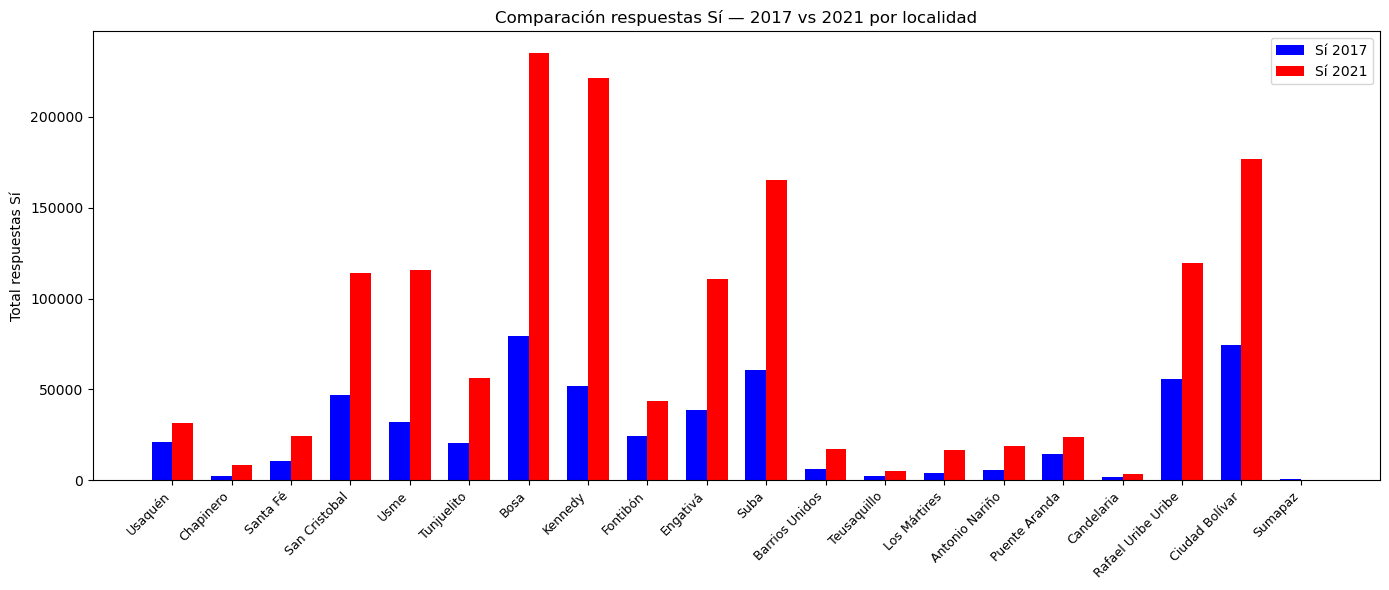

In [35]:
#Graficacion del contexto

localidades = df_BogAlime["Localidad"]
si_2017 = df_BogAlime["Total_Si_2017"]
si_2021 = df_BogAlime["Total_Si_2021"]

x = np.arange(len(localidades))

fig, ax = plt.subplots(figsize=(14, 6))

ancho = 0.35
ax.bar(x - ancho/2, si_2017, ancho, label="Sí 2017", color="blue")
ax.bar(x + ancho/2, si_2021, ancho, label="Sí 2021", color="red")

ax.set_xticks(x)
ax.set_xticklabels(localidades, rotation=45, ha="right", fontsize=9)
ax.set_ylabel("Total respuestas Sí")
ax.set_title("Comparación respuestas Sí — 2017 vs 2021 por localidad")
ax.legend()

plt.tight_layout()
plt.show()